In [3]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [5]:
import medmnist
from medmnist import INFO, Evaluator

In [31]:
# Import local files
%load_ext autoreload
%autoreload 2
from training import get_semi_supervised_labels, SSLDataset, train_loop_labeled, train_loop_unlabeled
from plots import plot_loss_curves, plot_accuracy_curve
from cnn import CNN

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [37]:
info

{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [ ]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

## Fully Labeled Dataset
What kind of performance can we get?

In [26]:
cnn_labeled = CNN(n_channels, n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_labeled.parameters(), lr=0.001)

train_history = train_loop_labeled(cnn_labeled, train_loader, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:04<00:00, 13.30it/s]


Epoch 1/20 | Train Loss: 0.9425 | Val Loss: 0.8597 | Val Acc: 0.6919


100%|██████████| 55/55 [00:04<00:00, 13.25it/s]


Epoch 2/20 | Train Loss: 0.7996 | Val Loss: 0.8365 | Val Acc: 0.6989


100%|██████████| 55/55 [00:04<00:00, 13.24it/s]


...

Epoch 18/20 | Train Loss: 0.3451 | Val Loss: 0.7717 | Val Acc: 0.7498


100%|██████████| 55/55 [00:04<00:00, 13.23it/s]


Epoch 19/20 | Train Loss: 0.3173 | Val Loss: 0.8276 | Val Acc: 0.7458


100%|██████████| 55/55 [00:04<00:00, 13.26it/s]


Epoch 20/20 | Train Loss: 0.2941 | Val Loss: 0.9139 | Val Acc: 0.7079


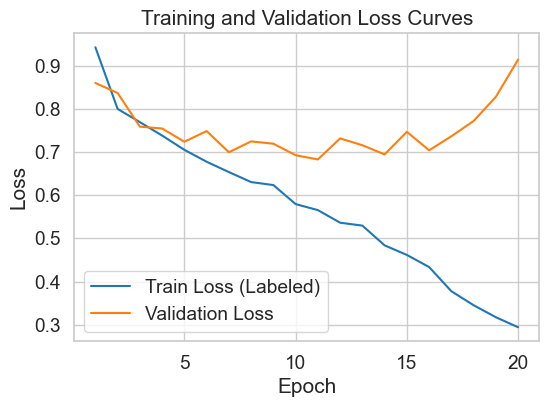

In [35]:
plot_loss_curves(train_history)

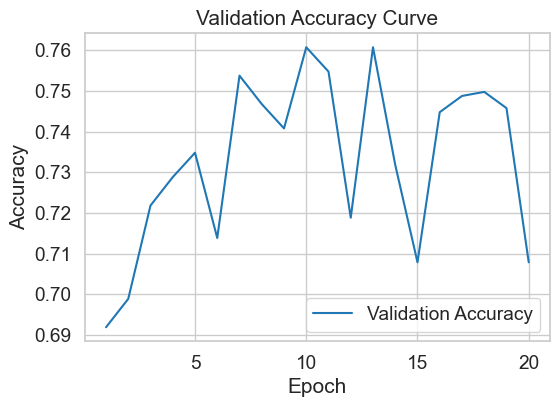

In [36]:
plot_accuracy_curve(train_history)

In [ ]:
# TODO: med mnist uses AUC as an evaluation metric in addition to accuracy, we should also use that

## Create SSL versions of the dataset

In [10]:
RANDOM_SEED = 42

In [11]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5

# print(train_dataset.labels)
# print(train_dataset.imgs)
train_labels_ssl = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset = SSLDataset(train_dataset, train_labels_ssl)
train_ssl_loader = data.DataLoader(train_ssl_dataset, batch_size=BATCH_SIZE, shuffle=True)

### Define the Baseline non-Bayesian CNN

In [14]:
# define a simple CNN model
model = CNN(in_channels=n_channels, num_classes=n_classes)
    
# define loss function and optimizer
criterion = nn.CrossEntropyLoss()

### Training Loop

In [15]:
NUM_EPOCHS = 3
lr = 0.001
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)


In [18]:
train_history = train_loop_labeled(model, train_ssl_loader, val_loader, criterion, optimizer, NUM_EPOCHS)

100%|██████████| 55/55 [00:02<00:00, 24.58it/s]


Epoch 1/3 | Train Loss: 0.9841 | Val Loss: 0.9453 | Val Acc: 0.6690


100%|██████████| 55/55 [00:02<00:00, 24.59it/s]


Epoch 2/3 | Train Loss: 0.9296 | Val Loss: 0.9245 | Val Acc: 0.6690


100%|██████████| 55/55 [00:02<00:00, 24.51it/s]


Epoch 3/3 | Train Loss: 0.9007 | Val Loss: 0.8837 | Val Acc: 0.6710


In [19]:
train_history

[{'epoch': 1,
  'train_loss': 0.9840669722232014,
  'val_loss': 0.9452588456577936,
  'val_acc': 0.6689930209371885,
  'train_total': 3506,
  'val_total': 1003},
 {'epoch': 2,
  'train_loss': 0.9296357004525522,
  'val_loss': 0.924516993885858,
  'val_acc': 0.6689930209371885,
  'train_total': 3506,
  'val_total': 1003},
 {'epoch': 3,
  'train_loss': 0.90074626935664,
  'val_loss': 0.8836522895697939,
  'val_acc': 0.67098703888335,
  'train_total': 3506,
  'val_total': 1003}]